# VDF inspection and dataset test for one timestep

Notebook is used to inspect velocity distribution functions (VDFs) from one Vlasiator timestep.

The idea is to inspect VDFs from two selected region:
- Reconnection sample taken close to magnetotail reconnection region where non-Maxwellian distribution is expected.
- Lobe sample taken from lobes where Maxwellian distribution is expected.

Notebook has two purposes:

1. **Visual inspection**
    Check if the choosen regions produce the expected VDF shapes.

2. **Data format testing**
    Experiment with data format used to save the extracted data and inspecting the format.

This notebook is exploratory

In [1]:
"""Inspect and save VDF samples from one Vlasiator timestep.

Notebook loads one Vlasiator `.vlsv` file, selects one VDF from reconnection
and lobe region, plots them, and saves them as small dataset, which is then inspected.
"""
import os
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np


os.environ['PTNOLATEX']='1'
sys.path.insert(0, "/home/jysa/vdf-ml/externals/analysator")

import analysator as pt

In [2]:
t = 3408
VDFlim = 2e6
R_EARTH = 6.371e6

x_reconnection, y_reconnection, z_reconnection = -12, 0, 0
x_lobe, y_lobe, z_lobe = -12, 0, 3
coords = np.array([[x_reconnection*R_EARTH, y_reconnection*R_EARTH, z_reconnection*R_EARTH],
                  [x_lobe*R_EARTH, y_lobe*R_EARTH, z_lobe*R_EARTH]])
labels = np.array([1, 0])
label_names = ["reconnection", "lobe"]

fileLocation = "/wrk-vakka/group/spacephysics/vlasiator/2D/BCH/bulk/"
bulkName = "bulk.000"+str(t)+".vlsv"
fileName = fileLocation + bulkName

file = pt.vlsvfile.VlsvReader(fileName)

In [3]:
def expr_velocity(exprmaps, requestvariables=False):
    """
    Return bilk velocity for Analysator colormap plotting

    Parameters
    ----------
    exprmaps : dict 
        Dictionary containing the variables requested from the `.vlsv` file.
    requestvariables : bool, optional
        If true, return the names of reqiuired variables.

    returns
    -------
    list[str] or numpy.ndarray
        Required variable names, or the bulk velocity vector field.
    """

    if requestvariables is True:
        return ['rho', 'rho_v']

    rho = exprmaps['rho'][:,:]
    rhov = exprmaps['rho_v'][:,:,:]

    velocity = rhov / rho[:,:,None]

    return velocity

def extract_vdf(file,cid,box=-1, pop="avgs"):
    """
    Extract a 3D VDF from one Vlasiator cell.

    This function reads the sparse velocity-space data stored in a `.vlsv`
    file, places the values into a full velocity-space grid, sorts the grid by
    velocity coordinates, and returns the VDF as a dence NumPy array.

    Parameters
    ----------
    file : str
        Path to the `.vlsv` file.
    cid : int
        Spatial cell ID from which the VDF is extracted.
    box : int, optional
        If positive, crop the VDF around its maximum value using this value as
        the half-width of the crop in index space. If `-1`, return VDF.
    pop : str, optional
        Particle population name used by Analysator.

    Returns
    -------
    numpy.ndarray
        Dense 3D VDF array with dtype `float32`. The returned axis order `[vx, vy, vz]`.
    """

    assert cid>0
    f = pt.vlsvfile.VlsvReader(file)
    #read phase space density
    vcells = f.read_velocity_cells(cid, pop)
    keys = list(vcells.keys())
    values = list(vcells.values())

    #generate a velocity space
    size = f.get_velocity_mesh_size(pop)
    vids = np.arange(4 * 4 * 4 * int(size[0]) * int(size[1]) * int(size[2]))

    #put phase space density into array
    dist = np.zeros_like(vids,dtype=float)
    dist[keys] = values

    #sort vspace by velocity
    v = f.get_velocity_cell_coordinates(vids, pop)

    i = np.argsort(v[:,0],kind='stable')
    v = v[i]
    #vids = vids[i]
    dist = dist[i]

    j = np.argsort(v[:,1],kind='stable')
    v = v[j]
    #vids = vids[j]
    dist = dist[j]

    k = np.argsort(v[:,2],kind='stable')
    v = v[k]
    #vids = vids[k]
    dist = dist[k]
    dist = dist.reshape(4*int(size[0]),4*int(size[1]),4*int(size[2]))
    vdf=dist
    i,j,k = np.unravel_index(np.argmax(vdf), vdf.shape)
    len=int(box)
    if box >0:
        data=vdf[(i-len):(i+len),(j-len):(j+len),(k-len):(k+len)]
    else:
        data =vdf

    data=np.swapaxes(data,2,0)
    return np.array(data,dtype=np.float32)

INFO: Using backend module://matplotlib_inline.backend_inline
INFO: Using matplotlib version 3.10.9


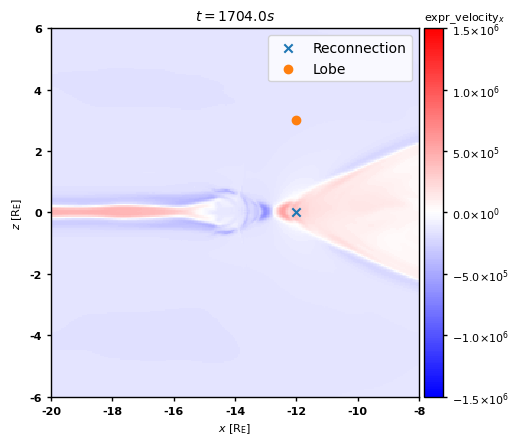

In [4]:
fig = plt.figure(figsize=(15,22))
ax1 = fig.add_subplot(411)

pt.plot.plot_colormap(filename=fileName,
                          axes=ax1,
                          boxre=[-20,-8,-6,6],
                          expression=expr_velocity , operator="x",
                          vmin=-1.5*1e+6,
                          vmax=1.5*1e+6,
                          )

ax1.scatter(x_reconnection, z_reconnection, marker="x", label="Reconnection")

ax1.scatter(x_lobe, z_lobe, marker="o", label="Lobe")

ax1.legend()

INFO: Getting offsets for population ion
INFO: V-space reduction via integration
INFO: Auto-switched to population 'avgs' for an old-style Vlasiator output
INFO: Found population avgs
INFO: 

INFO: cellid 3601751, x = -74850000.0, y = 0.0, z = 150000.0
INFO: Input velocity grid cell size 30000.0
INFO: Getting offsets for population avgs
INFO: Found 729792 v-space cells
INFO: Found a vlsv file MinValue of 8.301134972025815e-16
INFO: Dropping velocity cells under setThreshold value 8.301134972025815e-16
INFO: Performing slice with a counting thickness of 30000.0
INFO: Active f range is 2.490980114032101e-11 to 1.531902274302943e-07


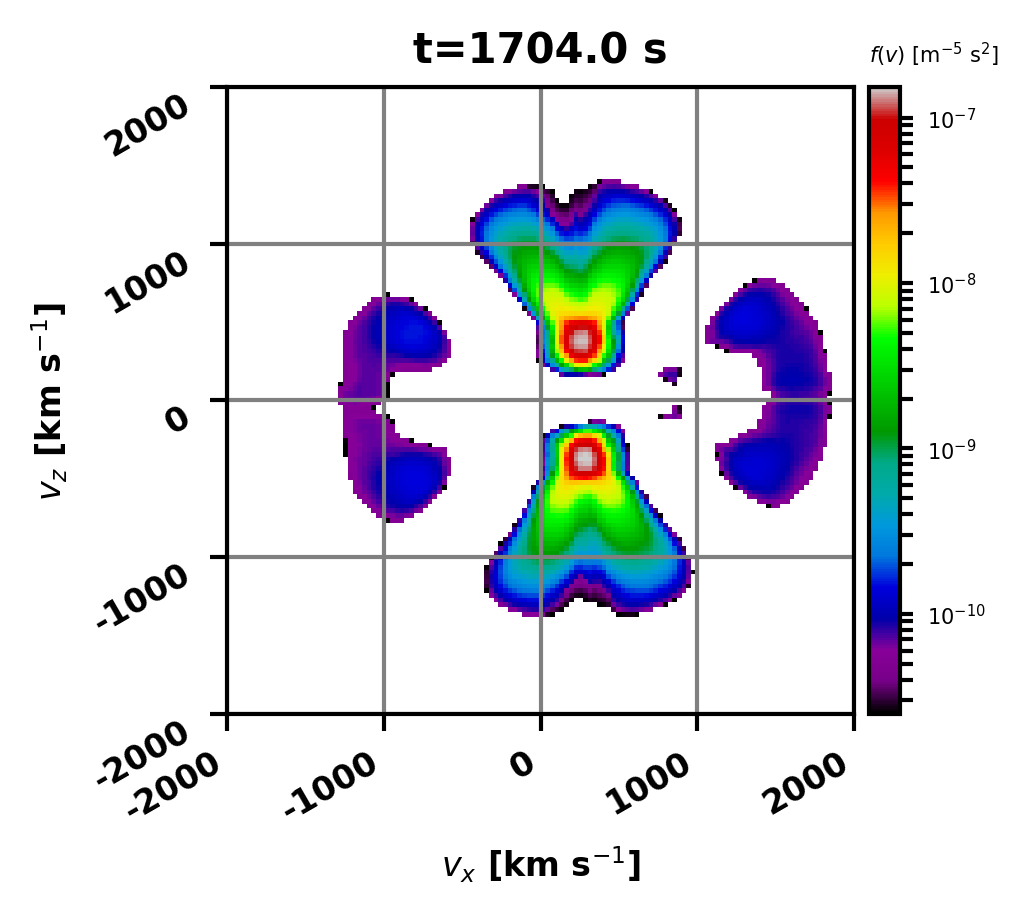

INFO: V-space reduction via integration
INFO: Auto-switched to population 'avgs' for an old-style Vlasiator output
INFO: Found population avgs
INFO: 

INFO: cellid 3751751, x = -74850000.0, y = 0.0, z = 15150000.0
INFO: Input velocity grid cell size 30000.0
INFO: Getting offsets for population avgs
INFO: Found 26624 v-space cells
INFO: Found a vlsv file MinValue of 2.9735100407476916e-16
INFO: Dropping velocity cells under setThreshold value 2.9735100407476916e-16
INFO: Performing slice with a counting thickness of 30000.0
INFO: Active f range is 9.528444883137647e-12 to 2.41805065553935e-07


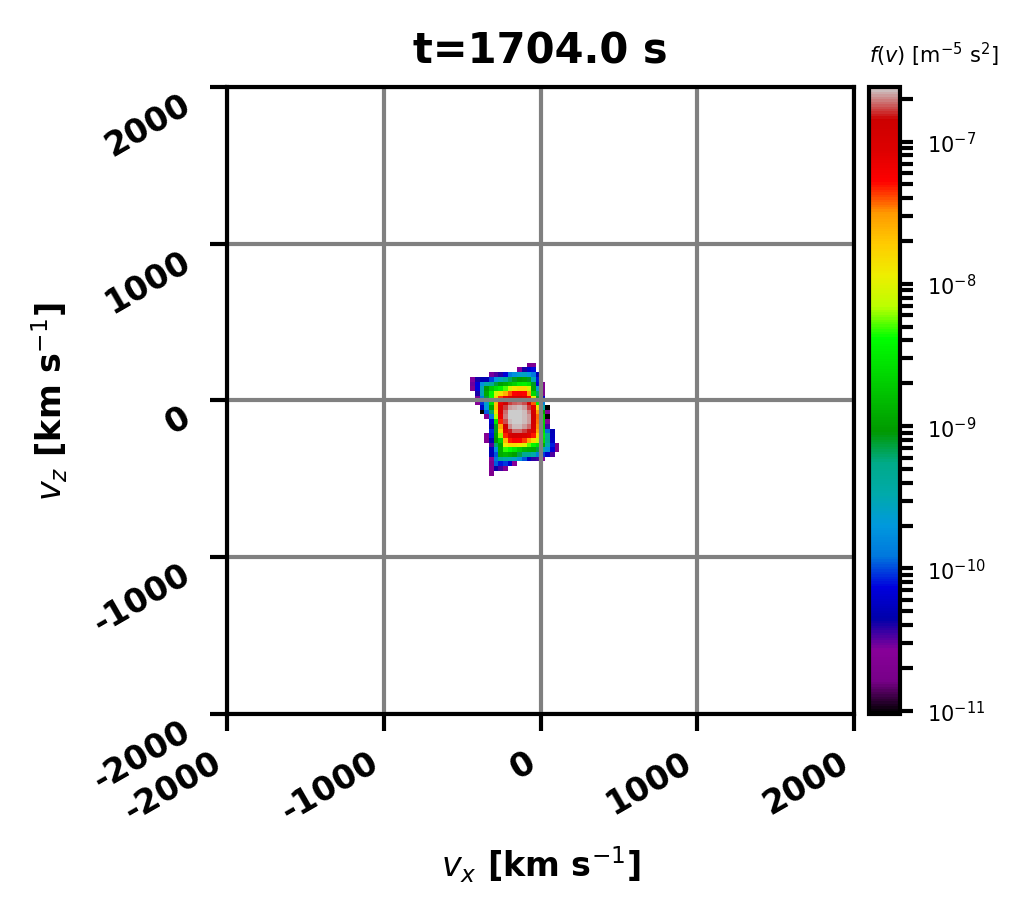

In [5]:
cids = []

for coord in coords:
    cid = file.get_cellid_with_vdf(coord, pop="ion")
    pt.plot.plot_vdf(filename=fileName,
                     cellids=[cid],
                     box=[-VDFlim,VDFlim,-VDFlim,VDFlim],
                     colormap='nipy_spectral',
                     xz=1,
                     draw=1)
    cids.append(cid)

# Improvements needed from this point forward

- Experimentation with the formation of the dataset.
- Additional data such as meta data needs to be saved.

In [6]:
X = []
y = []

for cid, label in zip(cids, labels):
    vdf = extract_vdf(
        fileName,
        cid=int(cid),
        )

    X.append(vdf)
    y.append(label)

X = np.stack(X).astype(np.float32)
y = np.array(y, dtype=np.int64)

INFO: Getting offsets for population avgs
INFO: Found population avgs
INFO: Getting offsets for population avgs
INFO: Found population avgs


In [7]:
project_root = Path.home() / "vdf-ml"
outdir = project_root / "data" / f"timestep_{int(t)}"
outdir.mkdir(parents=True, exist_ok=True)

In [8]:
np.savez_compressed(
    outdir / "vdfs.npz",
    X=X,
    y=y
)

In [9]:
data_dir = Path.home() / "vdf-ml" / "data" / f"timestep_{t}"

data = np.load(data_dir / "vdfs.npz")
X = data["X"]
y = data["y"]

print(X.shape)
print(y)
print(X)

(2, 268, 268, 268)
[1 0]
[[[[0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   ...
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]]

  [[0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   ...
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]]

  [[0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   ...
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]]

  ...

  [[0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   ...
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]]

  [[0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   ...
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]]

  [[0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   [0. 0. 0. ... 0. 0. 0.]
   ...
   [0. 0. 0. ... 0. 0. 0.

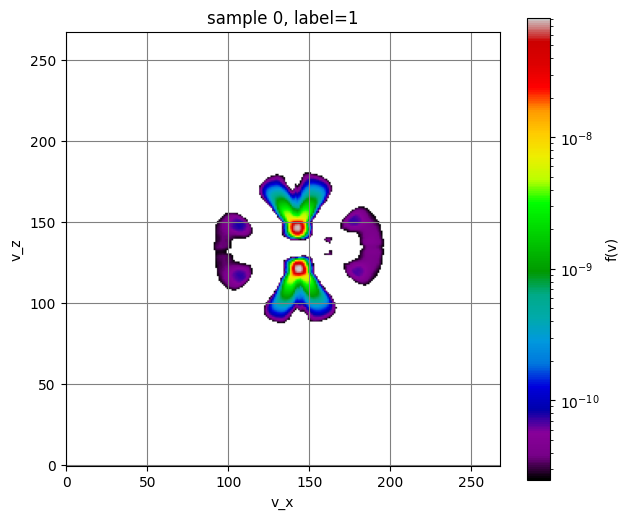

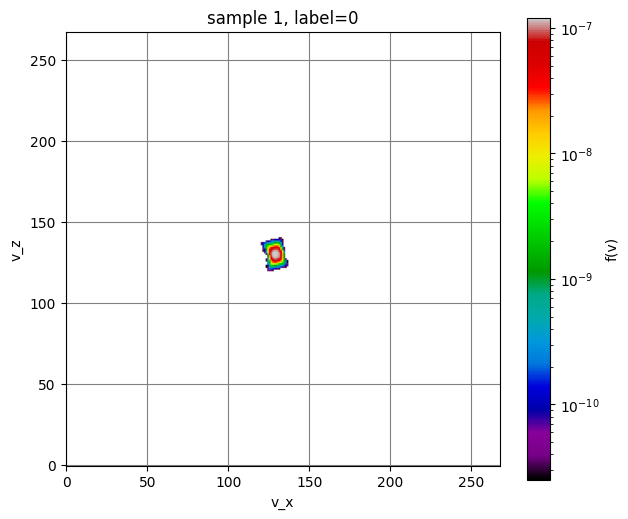

In [10]:
dv = 30000.0

for i, vdf in enumerate(X):
    
    vdf_swapped=np.swapaxes(vdf,2,0)

    fig, ax1 = plt.subplots(figsize=(7, 6))

    mid = vdf_swapped.shape[1] // 2

    vdf_plot = vdf_swapped[:, mid, :] * dv
    vdf_plot = np.where(vdf_plot < 8.301134972025815e-16 * dv, 0, vdf_plot)
    vdf_plot = np.ma.masked_less_equal(vdf_plot, 0)

    im = ax1.imshow(
        vdf_plot,
        origin="lower",

        norm="log",
        cmap="nipy_spectral",
    )

    ax1.grid(color="gray", axis="both")

    ax1.set_xlabel("v_x")
    ax1.set_ylabel("v_z")

    ax1.set_title(f"sample {i}, label={y[i]}")

    fig.colorbar(im, ax=ax1, label=r"f(v)")
    plt.show()